In [1]:
# %%
import numpy as np
import qiskit_nature
from qiskit_nature.units import DistanceUnit
from qiskit.quantum_info import SparsePauliOp
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper

qiskit_nature.settings.use_pauli_sum_op = False

n_qubit = 2
dim     = 2**n_qubit

# %%
bond_lengths = [0.2, 0.4, 0.6, 0.735, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]

# %%
nR = len(bond_lengths)
print(nR)
hamiltonians        = []
nuclear_energies    = []
print(bond_lengths)

# %%
for bond_length in bond_lengths:
    driver = PySCFDriver(
        atom="H 0 0 0; H 0 0 {bond_length}".format(bond_length=bond_length),
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )
    
    problem = driver.run()
    fermionic_op = problem.hamiltonian.second_q_op()
    mapper = ParityMapper(num_particles=problem.num_particles)
    hamiltonians.append(mapper.map(fermionic_op))
    nuclear_energies.append(problem.nuclear_repulsion_energy)

# %%
bond_lengths_fine = np.linspace(0.2,3.0,100)
bond_lengths_fine = np.sort(np.append(bond_lengths_fine,[0.735]))
nR_fine = len(bond_lengths_fine)

# %%
eigen_energies_fine  = np.zeros((nR_fine,dim),dtype=float)

# %%
iR_fine = 0
for bond_length in bond_lengths_fine:
    driver = PySCFDriver(
        atom="H 0 0 0; H 0 0 {bond_length}".format(bond_length=bond_length),
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )
    
    problem = driver.run()
    fermionic_op = problem.hamiltonian.second_q_op()
    mapper = ParityMapper(num_particles=problem.num_particles)
    h_qubit = mapper.map(fermionic_op)
    eigen_e, eigen_v = np.linalg.eigh(h_qubit.to_matrix())
    eigen_energies_fine[iR_fine,:] = eigen_e[:] + problem.nuclear_repulsion_energy
    iR_fine += 1

# %%
# filter non-computational basis eigenstate part to construct H_0
n_pauli = len(hamiltonians[0])
h0_list = []
h_list  = hamiltonians[0].to_list()
for ind in range(n_pauli):
    check = True
    for i_qubit in range(n_qubit):
        check = (h_list[ind][0][i_qubit] == 'I') or (h_list[ind][0][i_qubit] == 'Z')
        if not (check):
            break
    if check:
        h0_list.append(h_list[ind])
h0_qubit = SparsePauliOp.from_list(h0_list)
print(h0_qubit)

# %%
hamiltonians.insert(0,h0_qubit)
n_hamiltonians = len(hamiltonians)

# %%
for alpha in range(n_hamiltonians):
    print(alpha, hamiltonians[alpha])


# %%
hamiltonian_diffs = []
for alpha in range(n_hamiltonians-1):
    hamiltonian_diffs.append((hamiltonians[alpha+1]-hamiltonians[alpha]).simplify())
    print(hamiltonian_diffs[alpha])

# %%
hamiltonian_diffs_list = []
for alpha in range(n_hamiltonians-1):
    hamiltonian_diffs_list.append(hamiltonian_diffs[alpha].to_list())
    print(hamiltonian_diffs_list[alpha])

# %%
# exact eigenvalues
eigen_energies_exact  = np.zeros((n_hamiltonians,dim),dtype=float)
eigen_vectors_exact   = np.zeros((n_hamiltonians,dim,dim),dtype=complex)
for alpha in range(n_hamiltonians):
    eigen_e, eigen_v = np.linalg.eigh(hamiltonians[alpha].to_matrix())
    indx = np.argsort(eigen_e.real)
    for i in range(dim):
        eigen_energies_exact[alpha,i]   = eigen_e[indx[i]].real
        eigen_vectors_exact[alpha,:,i] = eigen_v[:,indx[i]]

# %%
# degenerate perturbation theory
import copy
nsec = 0
sec_list = []
done = [False]*dim
for i in range(dim):
    if done[i]:
        continue
    else:
        l = [i]
        done[i] =True
        for j in range(i+1,dim):
            if done[j]:
                continue
            else:
                if (np.abs(eigen_energies_exact[0,i]-eigen_energies_exact[0,j])<1E-8):
                    l.append(j)
                    done[j] = True
        sec_list.append(l)
#print(sec_list)
nsec = len(sec_list)
nesec = np.zeros(nsec,dtype=int)
for isec in range(nsec):
    nesec[isec] = len(sec_list[isec])
    #print(nesec[isec])
# diagonalize hamiltonian_diffs[0] for each degenerate sector
hp_mat = (eigen_vectors_exact[0,:,:].conj().transpose())@(hamiltonian_diffs[0].to_matrix())@eigen_vectors_exact[0,:,:]
#deps_sec = []
#w_sec   = []
for isec in range(nsec):
    hp_proj = np.zeros((nesec[isec],nesec[isec]),dtype=complex)
    for i in range(nesec[isec]):
        ii = sec_list[isec][i]
        for j in range(nesec[isec]):
            jj = sec_list[isec][j]
            hp_proj[i,j] = hp_mat[ii,jj]
    deps, w = np.linalg.eigh(hp_proj)
    v_t = np.zeros((dim,nesec[isec]),dtype=complex)

    for i in range(nesec[isec]):
        ii = sec_list[isec][i]
        v_t[:,i] = copy.deepcopy(eigen_vectors_exact[0,:,ii])
    for i in range(nesec[isec]):
        ii = sec_list[isec][i]
        eigen_vectors_exact[0,:,ii] = v_t@w[:,i]
    #print(deps,w)
    #deps_sec.append(deps)
    #w_sec.append(w)
#print(deps_sec,w_sec)
#print(eigen_vectors_exact[0,:,:])

# %%
def ExactTimeEvolution (alpha, time):
    Vl = copy.deepcopy(eigen_vectors_exact[alpha,:,:])
    evol = np.zeros((dim,dim),dtype=complex)
    exp_d = np.diag(np.exp(-1j*eigen_energies_exact[alpha,:]*time))
    evol = Vl@exp_d@Vl.conj().T
    return evol

# %%
# exact results
norms_exact  = np.ones((n_hamiltonians,dim),dtype=float)
for i in range(dim):
    phi = eigen_vectors_exact[0,:,i]
    for alpha in range(1,n_hamiltonians):
        proj_matrix = np.outer(eigen_vectors_exact[alpha,:,i],eigen_vectors_exact[alpha,:,i].conj())
        phi = proj_matrix@phi
        norms_exact[alpha,i] = phi.conj()@phi
        #print(phi.conj()@hamiltonians[alpha].to_matrix()@phi/norms_exact[alpha,i])
    #print('##')

# %%
for alpha in range(n_hamiltonians):
    print(norms_exact[alpha], eigen_energies_exact[alpha,:])

# %%
print(eigen_vectors_exact[0,:,0])
print(eigen_vectors_exact[0,:,1])
print(eigen_vectors_exact[0,:,2])
print(eigen_vectors_exact[0,:,3])


10
[0.2, 0.4, 0.6, 0.735, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]


/home/mchan/Doc/venv_qiskit/lib/python3.10/site-packages/pyscf/dft/libxc.py:772: UserWarning: Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, the same to the B3LYP functional in Gaussian and ORCA (issue 1480). To restore the VWN5 definition, you can put the setting "B3LYP_WITH_VWN5 = True" in pyscf_conf.py
  warnings.warn('Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, '


SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-0.63435785+0.j,  0.93048853+0.j, -0.93048853+0.j, -0.01362387+0.j])
0 SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-0.63435785+0.j,  0.93048853+0.j, -0.93048853+0.j, -0.01362387+0.j])
1 SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-0.63435785+0.j,  0.93048853+0.j, -0.93048853+0.j, -0.01362387+0.j,
  0.15797271+0.j])
2 SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-0.86257953+0.j,  0.68881943+0.j, -0.68881943+0.j, -0.01291397+0.j,
  0.16451542+0.j])
3 SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-1.00712708+0.j,  0.49401379+0.j, -0.49401379+0.j, -0.01206439+0.j,
  0.17373064+0.j])
4 SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-1.05237325+0.j,  0.39793742+0.j, -0.39793742+0.j, -0.0112801 +0.j,
  0.1809312 +0.j])
5 SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-1.06924349+0.j,  0.26752865+0.j, -0.2

/tmp/ipykernel_71500/1956985297.py:183: ComplexWarning: Casting complex values to real discards the imaginary part
  norms_exact[alpha,i] = phi.conj()@phi


In [2]:
import random as rd
import pickle

# %%
nmc = int(100)
beta = 5

# %%
# observable amplitudes
n_obs = 3

In [3]:
# run qzmc;

norms_qzmc               = np.ones((n_hamiltonians,dim),dtype=float)
eigen_energies_qzmc      = np.zeros((n_hamiltonians,dim),dtype=float)
eigen_energies_qzmc[0,:] = eigen_energies_exact[0,:]


result_values_save = [[[] for _ in range(n_hamiltonians)] for _ in range(dim)]


with open('H2.result.values','r') as file_:
    lines = file_.readlines()
    ind_line = 0
    for i in range(dim):
        for alpha in range(1,n_hamiltonians):
            result_values = []
            line = lines[ind_line]
            ls = line.split()
            for v in ls:
                result_values.append(float(v))
            #print(result_values)
            result_values_save[i][alpha] = result_values
            ind_line += 1


In [4]:
for i in range(dim):
    for alpha in range(1,n_hamiltonians):
        # compute values
        norm    = 0.0
        dE1     = 0.0
        dE2     = 0.0

        i_meas = 0
        # 0; norm
        for imc in range(nmc):
            norm += result_values_save[i][alpha][i_meas]
            i_meas += 1
        # 1; dE1
        nhd1 = len(hamiltonian_diffs[alpha-1])
        for ihd in range(nhd1):
            if (hamiltonian_diffs_list[alpha-1][ihd][0]=='I'*n_qubit):
                continue
            coeff = hamiltonian_diffs_list[alpha-1][ihd][1]
            for imc in range(nmc):
                dE1 +=  coeff * result_values_save[i][alpha][i_meas]
                i_meas += 1

        # 2; dE2
        if (alpha<n_hamiltonians-1):
            nhd2 = len(hamiltonian_diffs[alpha])
        else:
            nhd2 = 0
        for ihd in range(nhd2):
            if (hamiltonian_diffs_list[alpha][ihd][0]=='I'*n_qubit):
                continue
            coeff = hamiltonian_diffs_list[alpha][ihd][1]
            for imc in range(nmc):
                dE2 += coeff * result_values_save[i][alpha][i_meas]
                i_meas += 1
        
        dE1     /=norm
        dE2     /=norm

        norm    /=nmc

        # add constant contributions
        for ihd in range(nhd1):
            if (hamiltonian_diffs_list[alpha-1][ihd][0]=='I'*n_qubit):
                dE1 += hamiltonian_diffs_list[alpha-1][ihd][1]

        for ihd in range(nhd2):
            if (hamiltonian_diffs_list[alpha][ihd][0]=='I'*n_qubit):
                dE2 += hamiltonian_diffs_list[alpha][ihd][1]

        eigen_energies_qzmc[alpha,i] = eigen_energies_qzmc[alpha-1,i] + dE1
        norms_qzmc[alpha,i] = norm

        if (alpha<n_hamiltonians-1):
            eps = eigen_energies_qzmc[alpha,i] + dE2
            eps = eps.real
            
        print(alpha, norms_qzmc[alpha,i], eigen_energies_qzmc[alpha,i]-eigen_energies_exact[alpha,i])
        st = '# {i}/{dim}: {percent}%'.format(i=i+1,dim=dim,percent=((alpha)/(n_hamiltonians-1)*100))
        print(st)


1 0.7277644649831976 -0.0024310685247410646
# 1/4: 10.0%
2 0.733082174546405 -0.007984461776467722
# 1/4: 20.0%
3 0.7273585840889544 -0.00876156127085892
# 1/4: 30.0%
4 0.7291972440391653 -0.01053939962172179
# 1/4: 40.0%
5 0.6821885686593392 -0.01098060704921866
# 1/4: 50.0%
6 0.702161885133642 -0.014656656244409705
# 1/4: 60.0%
7 0.6619673173456454 -0.015065976397232284
# 1/4: 70.0%
8 0.6149940428374707 -0.019041371707357424
# 1/4: 80.0%
9 0.6099866603604748 -0.01748817702044292
# 1/4: 90.0%
10 0.6059125661217496 -0.015682723535239917
# 1/4: 100.0%
1 0.6865877025047596 0.005029733787822455
# 2/4: 10.0%
2 0.6936626229700582 0.010770866972289905
# 2/4: 20.0%
3 0.7135685751618989 0.013260296770522428
# 2/4: 30.0%
4 0.6954842177430414 0.01351663275136028
# 2/4: 40.0%
5 0.6971235863152809 0.011891141711389164
# 2/4: 50.0%
6 0.6743878049540047 0.010349676164372879
# 2/4: 60.0%
7 0.7283965027500908 0.010224026780850881
# 2/4: 70.0%
8 0.7282148670786871 0.009870614130553124
# 2/4: 80.0%
9 0.

/tmp/ipykernel_71500/2155547361.py:50: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_energies_qzmc[alpha,i] = eigen_energies_qzmc[alpha-1,i] + dE1


In [5]:
for iR in range(nR):
    eigen_energies_qzmc[iR+1,:] += nuclear_energies[iR]

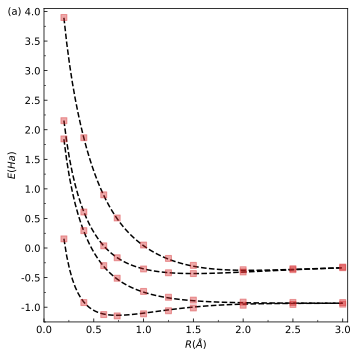

In [6]:
# draw figure
#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('pdf', 'svg')
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cm    = 1.0/2.54
rat   = 1.5
width = 8.6*cm * 1.5
height = 8.6*cm  * 1.5
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',color='black')

marker_style_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.4,  fillstyle='full')

marker_style_4  = dict(marker='s', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_5  = dict(marker='D', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_6  = dict(marker='x', linestyle='none', color='black', alpha=1.0,  fillstyle='none')


axes = []
#ax = plt.subplot2grid((2,2),(0,0), rowspan=2)
ax = plt.subplot2grid((1,1),(0,0))
axes.append(ax)
#ax = plt.subplot2grid((2,2),(0,1))
#axes.append(ax)
#ax = plt.subplot2grid((2,2),(1,1))
#axes.append(ax)

# plot (a)

y_min    = -1.25
y_max    =  4.05
#
x_min    =  0
x_max    =  3.05
#
axes[0].set_xlim(x_min,x_max)
axes[0].set_ylim(y_min,y_max)
# setup labels
axes[0].text(-0.12,0.98,'(a)',transform=axes[0].transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axes[0].set_xlabel(r'$R(\AA)$')
#axes[0].text(-0.25,0.5,r'$E(Ha)$',transform=axes[0].transAxes)
axes[0].set_ylabel(r'$E(Ha)$')
# setup tics
axes[0].tick_params(axis='x', which='both', direction='in')
axes[0].tick_params(axis='y', which='both', direction='in')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0].xaxis.set_major_formatter('{x:0.1f}')
axes[0].xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

axes[0].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0].yaxis.set_major_formatter('{x:0.1f}')
axes[0].yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

# plot
axes[0].plot(bond_lengths_fine,eigen_energies_fine, label='', **marker_style_ref)

axes[0].plot(bond_lengths,eigen_energies_qzmc[1:,:], label ='', markersize=6, **marker_style_1)
#axes[0,0].plot(lds,E_sim[:,1], label ='', markersize=6, **marker_style_1_2)
#
#axes[0,0].plot(lds,E_ibmq[:,0], label='', markersize=4, **marker_style_2_1)
#axes[0,0].plot(lds,E_ibmq[:,1], label='', markersize=4, **marker_style_2_2)
#
#axes[0,0].plot(lds,E_ibmq_em[:,0], label='', markersize=6, **marker_style_3_1)
#axes[0,0].plot(lds,E_ibmq_em[:,1], label='', markersize=6, **marker_style_3_2)
#
#
### plot (b)
##y_min    = -1.05
##y_max    =  1.05
##
##x_min    =  -0.05
##x_max    =  1.05
##
##axes[0,1].set_xlim(x_min,x_max)
##axes[0,1].set_ylim(y_min,y_max)
### setup labels
##axes[0,1].text(-0.25,0.95,'(b)',transform=axes[0,1].transAxes)
##axes[0,1].text(0.5,-0.2,s=r'$\lambda$',transform=axes[0,1].transAxes)
##axes[0,1].text(-0.25,0.5,s=r'$\langle O\rangle$',transform=axes[0,1].transAxes)
##
##
##axes[0,1].text(0.4,0.15,s=r'$X$',transform=axes[0,1].transAxes)
##axes[0,1].text(0.8,0.6,s=r'$Y$',transform=axes[0,1].transAxes)
##axes[0,1].text(0.38,0.8,s=r'$Z$',transform=axes[0,1].transAxes)
### setup tics
##axes[0,1].tick_params(axis='x', which='both', direction='in')
##axes[0,1].tick_params(axis='y', which='both', direction='in')
##axes[0,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
##axes[0,1].xaxis.set_major_formatter('{x:0.1f}')
##axes[0,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
##
##axes[0,1].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
##axes[0,1].yaxis.set_major_formatter('{x:0.1f}')
##axes[0,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.2))
##
### plot
##axes[0,1].plot(lds,Z_exact[:,0], label='', **marker_style_ref)
##axes[0,1].plot(lds,X_exact[:,0], label='', **marker_style_ref)
##axes[0,1].plot(lds,Y_exact[:,0], label='', **marker_style_ref)
##
##axes[0,1].plot(lds,Z_sim[:], label ='', markersize=4, **marker_style_1_1)
##axes[0,1].plot(lds,X_sim[:], label ='', markersize=4, **marker_style_1_2)
##axes[0,1].plot(lds,Y_sim[:], label ='', markersize=4, **marker_style_1_3)
##
##axes[0,1].plot(lds,Z_ibmq[:], label ='', markersize=4, **marker_style_2_1)
##axes[0,1].plot(lds,X_ibmq[:], label ='', markersize=4, **marker_style_2_2)
##axes[0,1].plot(lds,Y_ibmq[:], label ='', markersize=4, **marker_style_2_3)
##
##axes[0,1].plot(lds,Z_ibmq_em[:], label ='', markersize=4, **marker_style_3_1)
##axes[0,1].plot(lds,X_ibmq_em[:], label ='', markersize=4, **marker_style_3_2)
##axes[0,1].plot(lds,Y_ibmq_em[:], label ='', markersize=4, **marker_style_3_3)
##
### plot (c)
##y_min    = 0.0
##y_max    = 1.05
##
##x_min    =  -0.05
##x_max    =  1.05
##
##axes[1,0].set_xlim(x_min,x_max)
##axes[1,0].set_ylim(y_min,y_max)
### setup labels
##axes[1,0].text(-0.25,0.95,'(c)',transform=axes[1,0].transAxes)
##axes[1,0].text(0.5,-0.2,r'$\lambda$',transform=axes[1,0].transAxes)
##axes[1,0].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[1,0].transAxes)
### setup tics
##axes[1,0].tick_params(axis='x', which='both', direction='in')
##axes[1,0].tick_params(axis='y', which='both', direction='in')
##axes[1,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
##axes[1,0].xaxis.set_major_formatter('{x:0.1f}')
##axes[1,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
##
###axes[1,0].set_yscale('log')
##axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
##axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
##axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
##
### plot
##axes[1,0].plot(lds,norm_exact[:,0], label='', **marker_style_ref)
##
##axes[1,0].plot(lds[1:],norm_sim[1:,0], label ='noiseless', markersize=4, **marker_style_4)
##
##axes[1,0].plot(lds[1:],norm_ibmq[1:,0], label='ibmq_lima', markersize=4, **marker_style_5)
##
##axes[1,0].plot(lds[1:],norm_ibmq_em[1:,0], label='ibmq_lima (em)', markersize=4, **marker_style_6)
##
##axes[1,0].legend(loc='lower right')
##
### plot (d)
##y_min    = 0.0
##y_max    = 1.05
##
##x_min    =  -0.05
##x_max    =  1.05
##
##axes[1,1].set_xlim(x_min,x_max)
##axes[1,1].set_ylim(y_min,y_max)
### setup labels
##axes[1,1].text(-0.25,0.95,'(d)',transform=axes[1,1].transAxes)
##axes[1,1].text(0.5,-0.2,r'$\lambda$',transform=axes[1,1].transAxes)
##axes[1,1].text(-0.25,0.5,r'$\mathcal{F}$',transform=axes[1,1].transAxes)
### setup tics
##axes[1,1].tick_params(axis='x', which='both', direction='in')
##axes[1,1].tick_params(axis='y', which='both', direction='in')
##axes[1,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
##axes[1,1].xaxis.set_major_formatter('{x:0.1f}')
##axes[1,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
##
###axes[1,1].set_yscale('log')
##axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
##axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
##axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
##
### plot
##axes[1,1].axhline(y=1.0, label='', **marker_style_ref)
##
##axes[1,1].plot(lds[1:],F_sim[1:], label ='noiseless', markersize=4, **marker_style_4)
##
##axes[1,1].plot(lds[1:],F_ibmq[1:], label='ibmq_lima', markersize=4, **marker_style_5)
##
##axes[1,1].plot(lds[1:],F_ibmq_em[1:], label='ibmq_lima(em)', markersize=4, **marker_style_6)
##axes[1,1].legend(loc='lower right')

plt.tight_layout()

In [9]:
with open('H2.qzmc.energies','w') as file_:
    s = '# U, E_k(U), norm_k^2(U), k = 1,..'
    for iR in range(nR):
        s = '{:.16e}'.format(bond_lengths[iR])
        for i in range(dim):
            s += '  {:.16e}'.format(eigen_energies_qzmc[iR+1,i])
        s += '\n'
        file_.write(s)

In [10]:
with open('H2.fine.energies','w') as file_:
    s = '# U, E_{exact,k}(U)'
    for iR in range(nR_fine):
        s = '{:.16e}'.format(bond_lengths_fine[iR])
        for i in range(dim):
            s += '  {:.16e}'.format(eigen_energies_fine[iR,i])
        s += '\n'
        file_.write(s)